# IMPLEMENTATION NOTEBOOK

The goal is implementing (possibly manifold) CNFs in Jax. 
But first I have to learn how to use it. 
We go step by step, starting from vamps, gradients, etc.

In [1]:
import jax

## Equinox

Equinox is Jax's library for neural networks. 
Apparently they are written in a "pytorch like" way.
I have no idea, obviously. 
But let's see.
I think it's better if I start defining functions directly like this, so that it will be easier to extend later.

In [2]:
import equinox as eqx
import jax.numpy as jnp
from jax import random


class VelocityField(eqx.Module):
    params: jax.Array

    # Define the function to work on a single time and state
    def __call__(self, t, x):
        return -t * self.params @ x

key = random.PRNGKey(0)
key, subkey = random.split(key)

batch_size = 5
d = (2,)
X = random.uniform(subkey, shape=(batch_size,*d))
key, subkey = random.split(key)
ts = random.uniform(subkey, shape=(batch_size,))

vf = VelocityField(params=jnp.array([[0.1, 0.2], [0.3, 0.4]]))
# Here we test the velocity field on a single time and state
vf(ts[1], X[0])

# Now we can use vmap to apply it over batches of times and states
batched_vf = jax.vmap(vf, in_axes=(0, 0))
batched_vf(ts, X)

# Define a simple loss function
# JIT compile it for efficiency
@jax.jit
def loss(model, ts, X):
    preditions = jax.vmap(model)(ts, X)
    return jnp.mean(preditions)

loss(vf, ts, X)     # Single number

grad_loss = jax.grad(loss)  # Gradient funciton of the loss function wrt the first argument
grad_loss(vf, ts, X)    # Gradient function applied to an input

# The output is a VelocityField object with the same structure as vf
# We can access the gradients with respect to the parameters as
grad_loss(vf, ts, X).params

Array([[-0.03500895, -0.08331825],
       [-0.03500895, -0.08331825]], dtype=float32)

In [3]:
%timeit loss(vf, ts, X)  # Time the loss function

4.82 μs ± 105 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Diffrax

Diffrax is a package for differential equations in Jax. Of course, it natively supports adjoint methods. Let's see how it works.

In [4]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random


class VelocityField(eqx.Module):
    params: jax.Array

    # Time should always be the first argument for diffrax
    # It should also take an args variable
    def __call__(self, t, x, args):
        return -t * self.params @ x

velocity_field = VelocityField(params=jnp.array([[0.1, 0.2], [0.3, 0.4]]))
term = dfx.ODETerm(velocity_field)
solver = dfx.Dopri5()
stepsize_controller = dfx.PIDController(rtol=1e-5, atol=1e-5)
saveat = dfx.SaveAt(ts=jnp.linspace(0, 1, 10))

x0 = jnp.array([1.0, 0.0])
sol = dfx.diffeqsolve(
    term,
    solver,
    t0=0,
    t1=1,
    dt0=0.1,
    y0=x0,
    stepsize_controller=stepsize_controller,
    saveat=saveat,
    )

sol.ys  # The solution at the saved time points

Array([[ 1.        ,  0.        ],
       [ 0.999384  , -0.00184919],
       [ 0.9975458 , -0.00737573],
       [ 0.99453926, -0.01646407],
       [ 0.99044836, -0.02893429],
       [ 0.9853763 , -0.04456525],
       [ 0.9794461 , -0.06309456],
       [ 0.9728002 , -0.08421861],
       [ 0.96560043, -0.10759257],
       [ 0.95802826, -0.13283035]], dtype=float32)

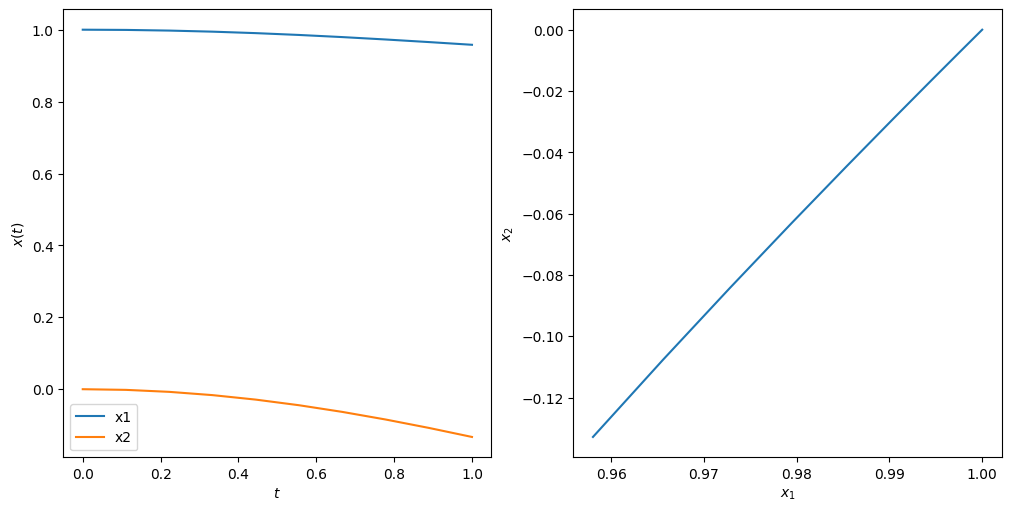

In [5]:
fig, axs = plt.subplots(1,2, figsize=(10,5), layout='constrained')
axs[0].plot(sol.ts, sol.ys[:, 0], label='x1')
axs[0].plot(sol.ts, sol.ys[:, 1], label='x2')
axs[0].legend()
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$x(t)$')
axs[1].plot(sol.ys[:, 0], sol.ys[:, 1])
axs[1].set_xlabel(r'$x_1$')
axs[1].set_ylabel(r'$x_2$')
plt.show()

In [6]:
# Optimise-then-discretise adjoint method

@jax.jit
def loss(velocity_field, x0):
    term = dfx.ODETerm(velocity_field)
    solver = dfx.Dopri5()
    stepsize_controller = dfx.PIDController(rtol=1e-5, atol=1e-5)
    saveat = dfx.SaveAt(ts=jnp.linspace(0, 1, 10))
    adjoint=dfx.BacksolveAdjoint()  # This does optimise‐then‐discretise (NOT RECOMMENDED)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=1,
        dt0=0.1,
        y0=x0,
        stepsize_controller=stepsize_controller,
        saveat=saveat,
        adjoint=adjoint,
        )
    return jnp.mean(sol.ys[-1])

x0 = jnp.array([1.0, 0.0])
loss(velocity_field, x0)

grad_loss = jax.grad(loss)
grad_loss(velocity_field, x0).params  # Gradient wrt the parameters

Array([[-0.22193633,  0.01618872],
       [-0.21059084,  0.015636  ]], dtype=float32)

## Distrax

Distrax is a package for probability distributions in Jax. I don't like the fact that the "documentation" assumes you know TensorFlows.

In [13]:
import distrax as dsx
import jax
import jax.numpy as jnp

# Google Example
key = jax.random.PRNGKey(1234)
mu = jnp.array([-1., 0., 1.])
sigma = jnp.array([0.1, 0.2, 0.3])
dist_distrax = dsx.MultivariateNormalDiag(mu, sigma)
samples = dist_distrax.sample(seed=key)
print(dist_distrax.log_prob(samples))

1.3209729


In [34]:
d = (2, 3)
M = 4
low = -jnp.ones(d)
high = jnp.ones(d)
uniform_distribution = dsx.Independent(dsx.Uniform(low, high), reinterpreted_batch_ndims=len(d))
samples = uniform_distribution.sample(seed=subkey, sample_shape=(M,))
samples, uniform_distribution.log_prob(samples)

(Array([[[ 0.86596394, -0.85926557, -0.96316457],
         [-0.86561584, -0.16339302,  0.40689445]],
 
        [[-0.36441207, -0.6730921 ,  0.6247344 ],
         [-0.07976961, -0.8351159 , -0.4253745 ]],
 
        [[-0.9878707 ,  0.30763078,  0.26717353],
         [-0.93852234, -0.79951024, -0.22400022]],
 
        [[ 0.46390152, -0.32334542, -0.04885721],
         [ 0.38970137,  0.75871515, -0.17349362]]], dtype=float32),
 Array([-4.158883, -4.158883, -4.158883, -4.158883], dtype=float32))

## Implementation test

In [ ]:
# import jax
# import jax.numpy as jnp
# import equinox as eqx
# import diffrax as dfx
# from typing import Callable, Optional, Dict, Any

# class Flow(eqx.Module):
#     velocity_field: Callable
#     base_distribution: Callable
#     solver: dfx.AbstractSolver = eqx.field(
#         default_factory=lambda: dfx.Tsit5(),
#         static=True,
#         )
#     augmented_solver: dfx.AbstractSolver = eqx.field(
#         default_factory=lambda: dfx.Tsit5(),
#         static=True,
#         )
#     t0: float = 0.0
#     t1: float = 1.0
#     dt0: Optional[float] = None
#     stepsize_controller: dfx.AbstractStepSizeController = eqx.field(
#         default_factory=lambda: dfx.PIDController(rtol=1e-5, atol=1e-5),
#         static=True,
#     )
#     augmented_stepsize_controller: dfx.AbstractStepSizeController = eqx.field(
#         default_factory=lambda: dfx.PIDController(rtol=1e-5, atol=1e-5),
#         static=True,
#     )
#     extra_args: Dict[str, Any] = eqx.field(default_factory=dict, static=True)
#     augmented_extra_args: Dict[str, Any] = eqx.field(default_factory=dict, static=True)

#     @eqx.filter_jit
#     def integrate(self, x0, **kwargs):
#         solver_args = dict(
#             solver=self.solver,
#             t0=self.t0,
#             t1=self.t1,
#             dt0=self.dt0,
#             stepsize_controller=self.stepsize_controller,
#             **self.extra_args,
#         )
#         solver_args.update(kwargs)
#         if solver_args["dt0"] is not None:
#             solver_args["dt0"] = jnp.sign(solver_args["t1"] - solver_args["t0"]) * abs(solver_args["dt0"])

#         term = dfx.ODETerm(self.velocity_field)
#         sol = dfx.diffeqsolve(term, y0=x0, **solver_args)
#         return sol

#     @eqx.filter_jit
#     def apply_map(self, x0, **kwargs):
#         saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
#         sol = self.integrate(x0, saveat=saveat, **kwargs)
#         return jax.tree.map(lambda y: y[-1], sol.ys)

#     @eqx.filter_jit
#     def apply_inverse_map(self, x1, **kwargs):
#         t0 = kwargs.pop("t0", self.t0)
#         t1 = kwargs.pop("t1", self.t1)
#         saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
#         sol = self.integrate(x1, t0=t1, t1=t0, saveat=saveat, **kwargs)
#         return jax.tree.map(lambda y: y[-1], sol.ys)

#     @eqx.filter_jit
#     def velocity_and_divergence(self, t, x, args=None):
#         x_flat, unravel = jax.flatten_util.ravel_pytree(x)
#         def v_flat(x_flat_):
#             x_unravelled = unravel(x_flat_)
#             v = self.velocity_field(t, x_unravelled, args)
#             v_flattened, _ = jax.flatten_util.ravel_pytree(v)
#             return v_flattened
#         y_flat, jvp_fun = jax.linearize(v_flat, x_flat)
#         v = unravel(y_flat)
#         I = jnp.eye(x_flat.size)
#         cols = jax.vmap(jvp_fun)(I)
#         divergence = jnp.trace(cols)
#         return v, divergence

#     @eqx.filter_jit
#     def augmented_velocity_field(self, t, y, args=None):
#         v, div_v = self.velocity_and_divergence(t, y["x"], args)
#         return {"x": v, "logq": -div_v}

#     @eqx.filter_jit
#     def integrate_augmented_ode(
#         self,
#         x0,
#         logq0=None,
#         **kwargs,
#         ):
#         solver_args = dict(
#             solver=self.augmented_solver,
#             t0=self.t0,
#             t1=self.t1,
#             dt0=self.dt0,
#             stepsize_controller=self.augmented_stepsize_controller,
#             **self.augmented_extra_args,
#         )
#         solver_args.update(kwargs)
#         if solver_args["dt0"] is not None:
#             solver_args["dt0"] = jnp.sign(solver_args["t1"] - solver_args["t0"]) * abs(solver_args["dt0"])

#         if logq0 is None:
#             logq0 = self.base_distribution.log_prob(x0)

#         y0 = {"x": x0, "logq": logq0}
#         term = dfx.ODETerm(self.augmented_velocity_field)
#         sol = dfx.diffeqsolve(term, y0=y0, **solver_args)
#         return sol

#     @eqx.filter_jit
#     def apply_map_and_log_prob(self, x0, **kwargs):
#         saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
#         sol = self.integrate_augmented_ode(x0, saveat=saveat, **kwargs)
#         x1 = jax.tree.map(lambda y: y[-1], sol.ys["x"])
#         logq1 = sol.ys["logq"][-1]
#         return x1, logq1

#     @eqx.filter_jit
#     def log_prob(self, x1, **kwargs):
#         f = jnp.zeros_like(self.base_distribution.log_prob(x1))
#         t0 = kwargs.pop("t0", self.t0)
#         t1 = kwargs.pop("t1", self.t1)
#         saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
#         sol = self.integrate_augmented_ode(x1, t0=t1, t1=t0, logq0=f, saveat=saveat, **kwargs)
#         x0 = jax.tree.map(lambda y: y[-1], sol.ys["x"])
#         f0 = sol.ys["logq"][-1]
#         logq0 = self.base_distribution.log_prob(x0)
#         return logq0 - f0

In [ ]:
from typing import Any, Callable, Dict, Optional

import diffrax as dfx
import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp


def _compute_velocity_and_divergence(velocity_field, t, x, args):
    """Computes velocity and divergence without referencing the Flow object."""
    x_flat, unravel = jax.flatten_util.ravel_pytree(x)

    def v_flat(x_flat_):
        x_unravelled = unravel(x_flat_)
        v = velocity_field(t, x_unravelled, args)
        v_flattened, _ = jax.flatten_util.ravel_pytree(v)
        return v_flattened

    y_flat, jvp_fun = jax.linearize(v_flat, x_flat)
    v = unravel(y_flat)
    I = jnp.eye(x_flat.size)
    cols = jax.vmap(jvp_fun)(I)
    divergence = jnp.trace(cols)
    return v, divergence

def _augmented_dynamics(t, y, args, velocity_field):
    """The actual ODE system to be solved."""
    v, div_v = _compute_velocity_and_divergence(velocity_field, t, y["x"], args)
    return {"x": v, "logq": -div_v}

class Flow(eqx.Module):
    velocity_field: Callable
    base_distribution: Callable
    solver: dfx.AbstractSolver = eqx.field(
        default_factory=lambda: dfx.Tsit5(),
        static=True,
    )
    augmented_solver: dfx.AbstractSolver = eqx.field(
        default_factory=lambda: dfx.Tsit5(),
        static=True,
    )
    t0: float = 0.0
    t1: float = 1.0
    dt0: Optional[float] = None
    stepsize_controller: dfx.AbstractStepSizeController = eqx.field(
        default_factory=lambda: dfx.PIDController(rtol=1e-5, atol=1e-5),
        static=True,
    )
    augmented_stepsize_controller: dfx.AbstractStepSizeController = eqx.field(
        default_factory=lambda: dfx.PIDController(rtol=1e-5, atol=1e-5),
        static=True,
    )
    extra_args: Dict[str, Any] = eqx.field(default_factory=dict, static=True)
    augmented_extra_args: Dict[str, Any] = eqx.field(default_factory=dict, static=True)

    @eqx.filter_jit
    def integrate(self, x0, **kwargs):
        solver_args = dict(
            solver=self.solver,
            t0=self.t0,
            t1=self.t1,
            dt0=self.dt0,
            stepsize_controller=self.stepsize_controller,
            **self.extra_args,
        )
        solver_args.update(kwargs)
        if solver_args["dt0"] is not None:
            solver_args["dt0"] = jnp.sign(solver_args["t1"] - solver_args["t0"]) * abs(solver_args["dt0"])

        term = dfx.ODETerm(lambda t, y, args: self.velocity_field(t, y, args))
        sol = dfx.diffeqsolve(term, y0=x0, **solver_args)
        return sol

    @eqx.filter_jit
    def apply_map(self, x0, **kwargs):
        saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
        sol = self.integrate(x0, saveat=saveat, **kwargs)
        return jax.tree.map(lambda y: y[-1], sol.ys)

    @eqx.filter_jit
    def apply_inverse_map(self, x1, **kwargs):
        t0 = kwargs.pop("t0", self.t0)
        t1 = kwargs.pop("t1", self.t1)
        saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
        sol = self.integrate(x1, t0=t1, t1=t0, saveat=saveat, **kwargs)
        return jax.tree.map(lambda y: y[-1], sol.ys)

    @eqx.filter_jit
    def integrate_augmented_ode(self, x0, logq0=None, **kwargs):
        solver_args = dict(
            solver=self.augmented_solver,
            t0=self.t0,
            t1=self.t1,
            dt0=self.dt0,
            stepsize_controller=self.augmented_stepsize_controller,
            **self.augmented_extra_args,
        )
        solver_args.update(kwargs)
        if solver_args["dt0"] is not None:
            solver_args["dt0"] = jnp.sign(solver_args["t1"] - solver_args["t0"]) * abs(solver_args["dt0"])

        if logq0 is None:
            logq0 = self.base_distribution.log_prob(x0)

        y0 = {"x": x0, "logq": logq0}

        term_func = jax.tree_util.Partial(_augmented_dynamics, velocity_field=self.velocity_field)
        term = dfx.ODETerm(term_func)

        sol = dfx.diffeqsolve(term, y0=y0, **solver_args)
        return sol

    @eqx.filter_jit
    def apply_map_and_log_prob(self, x0, **kwargs):
        saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
        sol = self.integrate_augmented_ode(x0, saveat=saveat, **kwargs)
        x1 = jax.tree.map(lambda y: y[-1], sol.ys["x"])
        logq1 = sol.ys["logq"][-1]
        return x1, logq1

    @eqx.filter_jit
    def log_prob(self, x1, **kwargs):
        f = jnp.zeros_like(self.base_distribution.log_prob(x1))
        t0 = kwargs.pop("t0", self.t0)
        t1 = kwargs.pop("t1", self.t1)
        saveat = kwargs.pop("saveat", dfx.SaveAt(t1=True))
        sol = self.integrate_augmented_ode(x1, t0=t1, t1=t0, logq0=f, saveat=saveat, **kwargs)
        x0 = jax.tree.map(lambda y: y[-1], sol.ys["x"])
        f0 = sol.ys["logq"][-1]
        logq0 = self.base_distribution.log_prob(x0)
        return logq0 - f0

### Array tests

In [8]:
import distrax as dsx

key = jax.random.PRNGKey(0)
d = (4,2)
M = 3
low = -jnp.ones(d)
high = jnp.ones(d)
uniform_dist = dsx.Independent(dsx.Uniform(low, high), reinterpreted_batch_ndims=len(d))
key, subkey = jax.random.split(key)
X0 = uniform_dist.sample(seed=subkey, sample_shape=(M,))
jax.vmap(uniform_dist.log_prob)(X0)

Array([-5.5451775, -5.5451775, -5.5451775], dtype=float32)

In [9]:
class VelocityField(eqx.Module):
    params: jax.Array

    def __call__(self, t, x, args):
        return -t * x @ self.params.T

key, subkey = jax.random.split(key)
params = jax.random.normal(subkey, (d[1], d[1]))
velocity_field = VelocityField(params=params)
t = 1.0
key, subkey = jax.random.split(key)
x = uniform_dist.sample(seed=subkey)
velocity_field(t, x, None)

flow = Flow(velocity_field=velocity_field, base_distribution=uniform_dist, dt0=0.1,
            extra_args={'max_steps':1000})
flow.integrate(x, dt0=0.01)
flow.apply_map(x)
flow.apply_inverse_map(x)

Array([[-0.592016  ,  1.3614821 ],
       [ 0.32442868,  1.0320221 ],
       [-0.24047366, -0.60416156],
       [-0.20235536,  1.0016961 ]], dtype=float32)

In [10]:
flow = Flow(
    velocity_field=velocity_field,
    base_distribution=uniform_dist,
    stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
    )
jnp.allclose(flow.apply_inverse_map(flow.apply_map(x0=x)), x, atol=1e-5, rtol=1e-5)

Array(True, dtype=bool)

In [12]:
_compute_velocity_and_divergence(flow.velocity_field, t=0.5, x=x, args=None)

(Array([[-0.41210106, -0.71468854],
        [ 0.7387791 ,  0.08104242],
        [-0.5012136 , -0.08815905],
        [ 0.0138595 , -0.33797485]], dtype=float32),
 Array(0.7581998, dtype=float32))

In [15]:
flow.integrate_augmented_ode(x)
x1, logq1 = flow.apply_map_and_log_prob(x)
logq1

Array(-6.303377, dtype=float32)

In [16]:
flow.log_prob(x1)

Array(-6.3033776, dtype=float32)

In [17]:
# Batched case

key, subkey = jax.random.split(key)
X0 = uniform_dist.sample(seed=subkey, sample_shape=(3,))

flow.base_distribution.log_prob(X0)

jax.vmap(flow.apply_map)(X0)
jax.vmap(flow.apply_map_and_log_prob)(X0)

(Array([[[-1.900593  , -0.61467165],
         [ 1.6957921 ,  0.37044555],
         [-0.19494274, -0.2694363 ],
         [ 0.14311586,  0.0868662 ]],
 
        [[-1.8018289 , -0.9525871 ],
         [-0.7968956 , -0.277562  ],
         [ 1.825628  ,  0.46416757],
         [-1.0581996 , -0.771121  ]],
 
        [[ 0.98992103, -0.09934205],
         [ 1.4530495 ,  0.7241253 ],
         [-0.2771487 , -0.19959557],
         [-1.8875036 , -0.49112362]]], dtype=float32),
 Array([-6.303377 , -6.303378 , -6.3033776], dtype=float32))

In [18]:
%timeit jax.vmap(flow.apply_map_and_log_prob)(X0)

814 μs ± 3.62 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Analytical check

In [20]:
key = jax.random.PRNGKey(0)
d = (1,)
low = -jnp.ones(d)
high = jnp.ones(d)
base_distribution = dsx.Independent(dsx.Uniform(low, high), reinterpreted_batch_ndims=len(d))

def velocity_field(t, x, args):
    return t * x**2

def true_solution(t, x0):
    return x0 / (1 - 0.5 * t**2 * x0)

def true_density_solution(t, f0, x0):
    return f0 + 2 * jnp.log(jnp.abs(1 - 0.5 * t**2 * x0))

batch_size = 10
key, subkey = jax.random.split(key)
X0 = base_distribution.sample(seed=subkey, sample_shape=(batch_size,))

flow = Flow(
    velocity_field=velocity_field,
    base_distribution=base_distribution,
    stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
    )

flow_result = jax.vmap(flow.apply_map)(X0)
true_result = jax.vmap(true_solution, in_axes=(None, 0))(1.0, X0)
assert jnp.allclose(flow_result, true_result)
inverse_flow_result = jax.vmap(flow.apply_inverse_map)(flow_result)
assert jnp.allclose(inverse_flow_result, X0)
augmented_flow_result, logq = jax.vmap(flow.apply_map_and_log_prob)(X0)
assert jnp.allclose(augmented_flow_result, true_result)
log_prob_flow_result = jax.vmap(flow.log_prob)(flow_result)
log_prob_augmented_result = jax.vmap(flow.log_prob)(augmented_flow_result)
assert jnp.allclose(logq, log_prob_flow_result, atol=1e-5, rtol=1e-5)
assert jnp.allclose(logq, log_prob_augmented_result, atol=1e-5, rtol=1e-5)
true_log_prob = jax.vmap(true_density_solution, in_axes=(None, 0, 0))(1.0, flow.base_distribution.log_prob(X0), X0)
assert jnp.allclose(logq, true_log_prob.reshape(-1), atol=1e-5, rtol=1e-5)
assert jnp.allclose(log_prob_flow_result, true_log_prob.reshape(-1), atol=1e-5, rtol=1e-5)
assert jnp.allclose(log_prob_augmented_result, true_log_prob.reshape(-1), atol=1e-4, rtol=1e-4)